<a href="https://colab.research.google.com/github/panvi5/DEFENSA/blob/main/NOISE%20CANCELLATION%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install speechbrain openai-whisper librosa soundfile scipy pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 9.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.1/782.1 kB 34.5 MB/s eta 0:00:00


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import torch

from scipy.signal import welch

warnings.filterwarnings("ignore")

SR = 16000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("Sample rate:", SR)

Device: cpu
Sample rate: 16000


In [ ]:
# ============================================================
# CELL 3 — EDGE-AI HUMAN VOICE DETECTION (VAD)
# ============================================================

import numpy as np
import librosa
import matplotlib.pyplot as plt

print("Running Human Voice Detection...")

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

VAD_FRAME = 512
VAD_HOP = 256

# Human speech frequency range
LOW_FREQ = 300
HIGH_FREQ = 3400

# ------------------------------------------------------------
# Create STFT
# ------------------------------------------------------------

D = librosa.stft(
    audio,
    n_fft=1024,
    hop_length=VAD_HOP,
    win_length=1024
)

magnitude = np.abs(D)

freqs = librosa.fft_frequencies(
    sr=SR,
    n_fft=1024
)

# ------------------------------------------------------------
# Speech frequency mask
# ------------------------------------------------------------

speech_band = (
    (freqs >= LOW_FREQ) &
    (freqs <= HIGH_FREQ)
)

# Energy in speech frequency band
speech_energy = np.mean(
    magnitude[speech_band, :] ** 2,
    axis=0
)

# Total energy
total_energy = np.mean(
    magnitude ** 2,
    axis=0
)

# ------------------------------------------------------------
# Speech-band ratio
# ------------------------------------------------------------

speech_ratio = (
    speech_energy /
    (total_energy + 1e-10)
)

# ------------------------------------------------------------
# Normalize
# ------------------------------------------------------------

speech_ratio_norm = (
    speech_ratio -
    np.min(speech_ratio)
) / (
    np.max(speech_ratio) -
    np.min(speech_ratio) +
    1e-10
)

# ------------------------------------------------------------
# Voice probability
# ------------------------------------------------------------

VOICE_THRESHOLD = 0.30

voice_probability = speech_ratio_norm

speech_detected = (
    voice_probability >= VOICE_THRESHOLD
)

# ------------------------------------------------------------
# Convert frame decision to time
# ------------------------------------------------------------

times = librosa.frames_to_time(
    np.arange(len(voice_probability)),
    sr=SR,
    hop_length=VAD_HOP
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

speech_percentage = (
    np.mean(speech_detected) * 100
)

print(
    f"Human Voice Detected in "
    f"{speech_percentage:.2f}% of audio"
)

if speech_percentage > 5:
    print("STATUS: HUMAN VOICE DETECTED")
else:
    print("STATUS: NO SIGNIFICANT HUMAN VOICE DETECTED")

# ------------------------------------------------------------
# Plot Voice Probability
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    times,
    voice_probability,
    label="Voice Probability"
)

plt.axhline(
    VOICE_THRESHOLD,
    linestyle="--",
    label="Voice Detection Threshold"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Voice Probability")
plt.title("Edge-AI Human Voice Detection / VAD")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No audio file uploaded.")

INPUT_FILE = list(uploaded.keys())[0]

print("Input:", INPUT_FILE)

Saving mm vedios.mp3 to mm vedios.mp3
Input: mm vedios.mp3


In [ ]:
audio, _ = librosa.load(
    INPUT_FILE,
    sr=SR,
    mono=True
)

audio = audio.astype(np.float32)

if len(audio) == 0:
    raise RuntimeError("Audio is empty.")

print("Duration:", round(len(audio) / SR, 2), "seconds")
print("Samples:", len(audio))

Duration: 8.41 seconds
Samples: 134490


In [ ]:
# Estimate noise from quietest 20% of frames

FRAME = 1024
HOP = 256

frames = librosa.util.frame(
    audio,
    frame_length=FRAME,
    hop_length=HOP
)

energy = np.mean(frames ** 2, axis=0)

threshold = np.percentile(energy, 20)

quiet = frames[:, energy <= threshold]

print("Total frames:", frames.shape[1])
print("Noise-estimation frames:", quiet.shape[1])

noise_psd_list = []

for i in range(quiet.shape[1]):
    f, p = welch(
        quiet[:, i],
        fs=SR,
        nperseg=FRAME
    )
    noise_psd_list.append(p)

if noise_psd_list:
    NOISE_PSD = np.mean(
        np.asarray(noise_psd_list),
        axis=0
    )
else:
    f, NOISE_PSD = welch(
        audio,
        fs=SR,
        nperseg=FRAME
    )

NOISE_PSD_DB = 10 * np.log10(
    NOISE_PSD + 1e-12
)

print("PSD noise profile ready.")

Total frames: 522
Noise-estimation frames: 105
PSD noise profile ready.


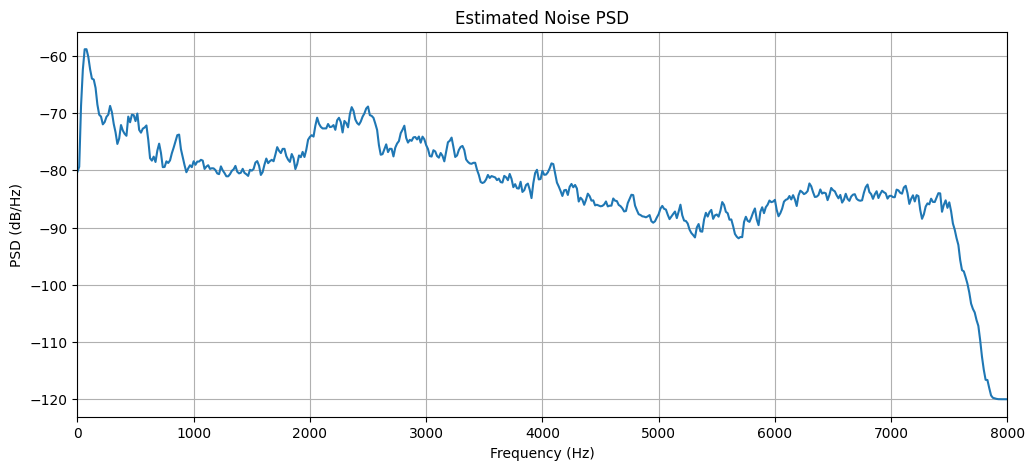

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    f,
    NOISE_PSD_DB
)

plt.xlim(0, 8000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("Estimated Noise PSD")
plt.grid(True)

plt.show()

In [ ]:
from speechbrain.inference.separation import SepformerSeparation

print("Loading AI enhancement model...")

model = SepformerSeparation.from_hparams(
    source="speechbrain/sepformer-dns4-16k-enhancement",
    savedir="/content/sepformer_dns4",
    run_opts={"device": DEVICE}
)

print("Model loaded.")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/sepformer-dns4-16k-enhancement' if not cached


Loading AI enhancement model...


hyperparams.yaml:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch encoder.ckpt: Fetching from HuggingFace Hub 'speechbrain/sepformer-dns4-16k-enhancement' if not cached


encoder.ckpt: reconstructing file:   0%|          |  0.00B / 17.3kB            

...

INFO:speechbrain.utils.fetching:Fetch decoder.ckpt: Fetching from HuggingFace Hub 'speechbrain/sepformer-dns4-16k-enhancement' if not cached


decoder.ckpt: reconstructing file:   0%|          |  0.00B / 17.2kB            

decoder.ckpt: downloading bytes:           |  0.00B            

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: encoder, masknet, decoder


Model loaded.


In [ ]:
print("Enhancing audio...")

result = model.separate_file(
    path=INPUT_FILE
)

print("Model output:", tuple(result.shape))

Enhancing audio...
Resampling the audio from 44100 Hz to 16000 Hz
Model output: (1, 134490, 1)


In [ ]:
enhanced_audio = (
    result[:, :, 0]
    .detach()
    .cpu()
    .numpy()
)

enhanced_audio = np.squeeze(
    enhanced_audio
).astype(np.float32)

enhanced_audio = enhanced_audio.reshape(-1)

# Match original length without random cropping

if len(enhanced_audio) > len(audio):
    enhanced_audio = enhanced_audio[:len(audio)]

elif len(enhanced_audio) < len(audio):
    enhanced_audio = np.pad(
        enhanced_audio,
        (0, len(audio) - len(enhanced_audio))
    )

print("Input samples :", len(audio))
print("Output samples:", len(enhanced_audio))

Input samples : 134490
Output samples: 134490


In [ ]:
EPS = 1e-10

input_rms = np.sqrt(
    np.mean(audio ** 2) + EPS
)

output_rms = np.sqrt(
    np.mean(enhanced_audio ** 2) + EPS
)

gain = input_rms / (output_rms + EPS)

# Avoid extreme volume changes
gain = np.clip(gain, 0.80, 1.25)

enhanced_audio = enhanced_audio * gain

# Safety limiter
peak = np.max(
    np.abs(enhanced_audio)
)

if peak > 0.98:
    enhanced_audio *= 0.98 / peak

print("Gain:", round(float(gain), 4))

Gain: 0.8


In [ ]:
OUTPUT_FILE = "/content/enhanced_audio.wav"

sf.write(
    OUTPUT_FILE,
    enhanced_audio,
    SR
)

print("Saved:", OUTPUT_FILE)

Saved: /content/enhanced_audio.wav


In [ ]:
from IPython.display import Audio, display

print("BEFORE")
display(Audio(audio, rate=SR))

print("AFTER")
display(Audio(enhanced_audio, rate=SR))

BEFORE


AFTER


In [ ]:
def rms_db(x):
    return float(
        20 * np.log10(
            np.sqrt(np.mean(x**2) + EPS)
        )
    )


def peak_db(x):
    return float(
        20 * np.log10(
            np.max(np.abs(x)) + EPS
        )
    )


def noise_floor(x):
    r = librosa.feature.rms(
        y=x,
        frame_length=1024,
        hop_length=256
    )[0]

    return float(
        np.percentile(
            20 * np.log10(r + EPS),
            20
        )
    )


def speech_energy(x):
    D = librosa.stft(
        x,
        n_fft=1024,
        hop_length=256
    )

    power = np.abs(D)**2

    freq = librosa.fft_frequencies(
        sr=SR,
        n_fft=1024
    )

    mask = (
        (freq >= 300) &
        (freq <= 3400)
    )

    return float(
        10 * np.log10(
            np.mean(power[mask]) + EPS
        )
    )


def high_energy(x):
    D = librosa.stft(
        x,
        n_fft=1024,
        hop_length=256
    )

    power = np.abs(D)**2

    freq = librosa.fft_frequencies(
        sr=SR,
        n_fft=1024
    )

    mask = freq >= 5000

    return float(
        10 * np.log10(
            np.mean(power[mask]) + EPS
        )
    )


def estimated_snr(x):
    r = librosa.feature.rms(
        y=x,
        frame_length=1024,
        hop_length=256
    )[0]

    power = r**2

    limit = np.percentile(
        power,
        20
    )

    noise = power[
        power <= limit
    ]

    if len(noise) == 0:
        return np.nan

    noise_power = np.mean(noise)
    total_power = np.mean(power)

    speech_power = max(
        total_power - noise_power,
        EPS
    )

    return float(
        10 * np.log10(
            speech_power /
            (noise_power + EPS)
        )
    )

In [ ]:
before = {
    "RMS (dB)": rms_db(audio),
    "Peak (dBFS)": peak_db(audio),
    "Noise Floor (dB)": noise_floor(audio),
    "Estimated SNR (dB)": estimated_snr(audio),
    "Speech Energy (dB)": speech_energy(audio),
    "High Frequency Energy (dB)": high_energy(audio)
}

after = {
    "RMS (dB)": rms_db(enhanced_audio),
    "Peak (dBFS)": peak_db(enhanced_audio),
    "Noise Floor (dB)": noise_floor(enhanced_audio),
    "Estimated SNR (dB)": estimated_snr(enhanced_audio),
    "Speech Energy (dB)": speech_energy(enhanced_audio),
    "High Frequency Energy (dB)": high_energy(enhanced_audio)
}

comparison = pd.DataFrame({
    "Parameter": list(before.keys()),
    "Before": list(before.values()),
    "After": list(after.values())
})

comparison["Change"] = (
    comparison["After"] -
    comparison["Before"]
)

display(comparison)

,Parameter,Before,After,Change
0,RMS (dB),-31.388535,-21.918617,9.469917
1,Peak (dBFS),-15.646233,-1.938200,13.708032
2,Noise Floor (dB),-34.700546,-40.398186,-5.697639
3,Estimated SNR (dB),3.148103,22.066025,18.917922
4,Speech Energy (dB),-2.922974,7.612887,10.535861
5,High Frequency Energy (dB),-15.930204,-15.216818,0.713387


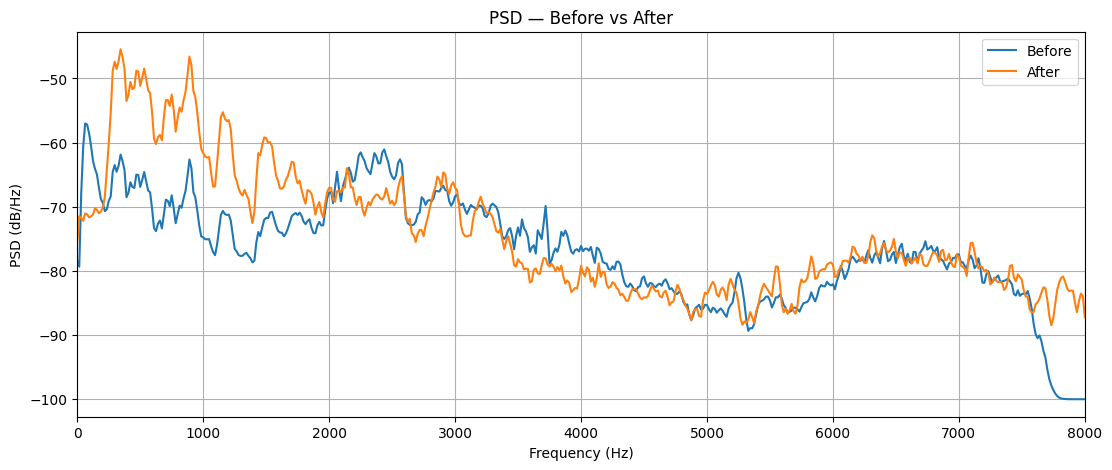

In [ ]:
f_before, p_before = welch(
    audio,
    fs=SR,
    nperseg=1024
)

f_after, p_after = welch(
    enhanced_audio,
    fs=SR,
    nperseg=1024
)

p_before_db = 10 * np.log10(
    p_before + EPS
)

p_after_db = 10 * np.log10(
    p_after + EPS
)

plt.figure(figsize=(13, 5))

plt.plot(
    f_before,
    p_before_db,
    label="Before"
)

plt.plot(
    f_after,
    p_after_db,
    label="After"
)

plt.xlim(0, 8000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("PSD — Before vs After")
plt.legend()
plt.grid(True)

plt.show()

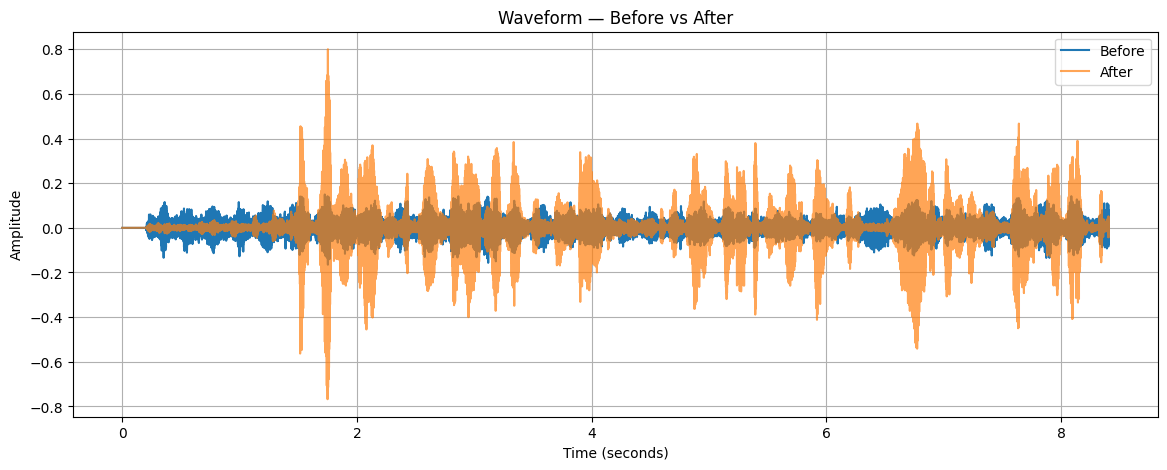

In [ ]:
t = np.arange(len(audio)) / SR

plt.figure(figsize=(14, 5))

plt.plot(
    t,
    audio,
    label="Before"
)

plt.plot(
    t,
    enhanced_audio,
    label="After",
    alpha=0.7
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Waveform — Before vs After")
plt.legend()
plt.grid(True)

plt.show()

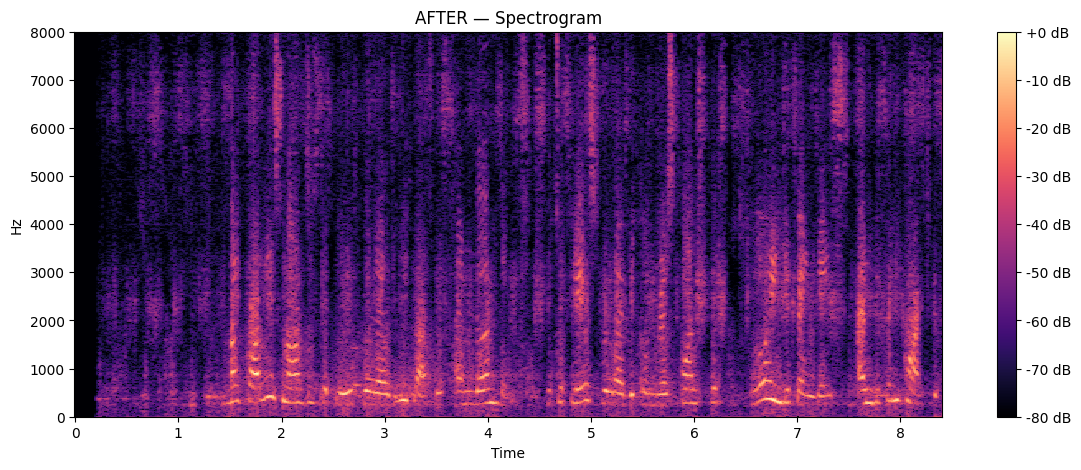

In [ ]:
D2 = librosa.stft(
    enhanced_audio,
    n_fft=1024,
    hop_length=256
)

S2 = librosa.amplitude_to_db(
    np.abs(D2),
    ref=np.max
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    S2,
    sr=SR,
    hop_length=256,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title("AFTER — Spectrogram")
plt.ylim(0, 8000)

plt.show()

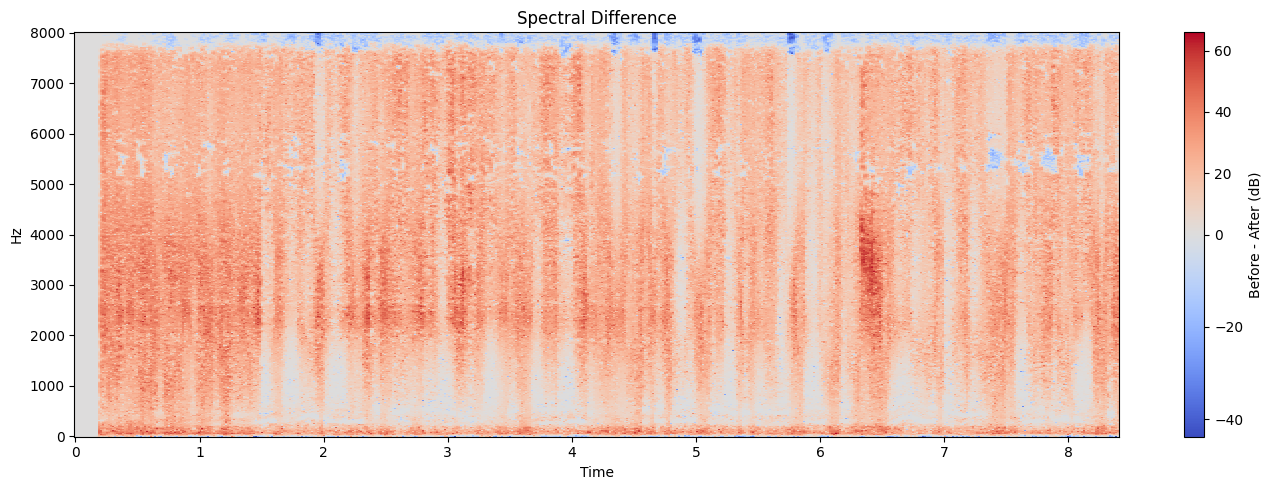

Spectral difference analysis completed.


In [ ]:
# ============================================================
# CELL 19 — SPECTRAL DIFFERENCE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import librosa

# Make sure both signals have the same length
min_len = min(len(audio), len(enhanced_audio))

before = np.asarray(audio[:min_len], dtype=np.float32)
after = np.asarray(enhanced_audio[:min_len], dtype=np.float32)

# STFT
D_before = librosa.stft(
    before,
    n_fft=1024,
    hop_length=256,
    win_length=1024
)

D_after = librosa.stft(
    after,
    n_fft=1024,
    hop_length=256,
    win_length=1024
)

# Magnitude difference in dB
mag_before = np.abs(D_before)
mag_after = np.abs(D_after)

diff_db = librosa.amplitude_to_db(
    np.maximum(mag_before, 1e-8),
    ref=np.max
) - librosa.amplitude_to_db(
    np.maximum(mag_after, 1e-8),
    ref=np.max
)

plt.figure(figsize=(14, 5))

librosa.display.specshow(
    diff_db,
    sr=SR,
    hop_length=256,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(label="Before - After (dB)")
plt.title("Spectral Difference")
plt.tight_layout()
plt.show()

print("Spectral difference analysis completed.")

In [ ]:
import whisper

print("Loading Whisper...")

whisper_model = whisper.load_model(
    "base",
    device=DEVICE
)

print("Whisper ready.")

Loading Whisper...


100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 97.3MiB/s]


Whisper ready.


In [ ]:
transcript = whisper_model.transcribe(
    OUTPUT_FILE,
    temperature=0,
    fp16=(DEVICE == "cuda")
)

print("Language:",
      transcript.get("language", "unknown"))

print()
print("TEXT:")
print(transcript["text"])

Language: en

TEXT:
 My call is not just a place where I will be passed this time-learning. It's a place where I become responsible for independent and independent practice.


In [ ]:
def srt_time(seconds):

    total_ms = int(
        round(seconds * 1000)
    )

    h = total_ms // 3600000
    total_ms %= 3600000

    m = total_ms // 60000
    total_ms %= 60000

    s = total_ms // 1000
    ms = total_ms % 1000

    return (
        f"{h:02d}:"
        f"{m:02d}:"
        f"{s:02d},"
        f"{ms:03d}"
    )


SRT_FILE = (
    "/content/enhanced_subtitles.srt"
)

with open(
    SRT_FILE,
    "w",
    encoding="utf-8"
) as f:

    number = 1

    for segment in transcript["segments"]:

        text = segment["text"].strip()

        if not text:
            continue

        f.write(
            f"{number}\n"
        )

        f.write(
            f"{srt_time(segment['start'])} --> "
            f"{srt_time(segment['end'])}\n"
        )

        f.write(
            f"{text}\n\n"
        )

        number += 1

print(
    "SRT created:",
    SRT_FILE
)

SRT created: /content/enhanced_subtitles.srt


In [ ]:
# ============================================================
# CELL 23 — SAVE REPORTS
# ============================================================

import os
import numpy as np
import pandas as pd

# Create output directory
OUTPUT_DIR = "/content/audio_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# Before / After parameters
# -----------------------------

def calculate_parameters(x, sr):
    x = np.asarray(x, dtype=np.float32)

    peak = float(np.max(np.abs(x)))
    rms = float(np.sqrt(np.mean(x ** 2)) + 1e-12)

    rms_db = float(20 * np.log10(rms + 1e-12))
    peak_db = float(20 * np.log10(peak + 1e-12))

    duration = float(len(x) / sr)

    return {
        "Duration_seconds": duration,
        "RMS": rms,
        "RMS_dB": rms_db,
        "Peak": peak,
        "Peak_dB": peak_db
    }


before_params = calculate_parameters(audio, SR)
after_params = calculate_parameters(enhanced_audio, SR)

parameter_table = pd.DataFrame({
    "Parameter": list(before_params.keys()),
    "Before": list(before_params.values()),
    "After": list(after_params.values())
})

# Difference column
parameter_table["Difference"] = (
    parameter_table["After"] - parameter_table["Before"]
)

PARAM_FILE = os.path.join(
    OUTPUT_DIR,
    "before_after_parameters.csv"
)

parameter_table.to_csv(
    PARAM_FILE,
    index=False
)

print("Before/After Parameters:")
display(parameter_table)

print("\nSaved:")
print(PARAM_FILE)


# -----------------------------
# Save PSD data if available
# -----------------------------

if "freqs" in globals() and "noise_psd" in globals():

    psd_table = pd.DataFrame({
        "Frequency_Hz": np.asarray(freqs),
        "Noise_PSD": np.asarray(noise_psd)
    })

    PSD_FILE = os.path.join(
        OUTPUT_DIR,
        "noise_psd.csv"
    )

    psd_table.to_csv(
        PSD_FILE,
        index=False
    )

    print("Saved:")
    print(PSD_FILE)

else:
    print("PSD variables not available. Skipping PSD CSV.")

Before/After Parameters:


,Parameter,Before,After,Difference
0,Duration_seconds,8.405625,8.405625,0.000000
1,RMS,0.026951,0.080181,0.053230
2,RMS_dB,-31.388537,-21.918617,9.469919
3,Peak,0.165078,0.800000,0.634922
4,Peak_dB,-15.646233,-1.938200,13.708032



Saved:
/content/audio_results/before_after_parameters.csv
PSD variables not available. Skipping PSD CSV.


In [ ]:
# ============================================================
# CELL 24 — CREATE FINAL ZIP
# ============================================================

import os
import zipfile

OUTPUT_DIR = "/content/audio_results"

# Make sure directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save enhanced audio again inside results folder
FINAL_AUDIO = os.path.join(
    OUTPUT_DIR,
    "enhanced_audio.wav"
)

sf.write(
    FINAL_AUDIO,
    enhanced_audio.astype(np.float32),
    SR,
    subtype="PCM_16"
)

print("Enhanced audio saved:")
print(FINAL_AUDIO)


# ------------------------------------------------------------
# Add subtitle file if it exists
# ------------------------------------------------------------

if "SRT_FILE" in globals() and os.path.exists(SRT_FILE):

    subtitle_destination = os.path.join(
        OUTPUT_DIR,
        "enhanced_subtitles.srt"
    )

    # Copy subtitle file
    with open(SRT_FILE, "r", encoding="utf-8") as src:
        subtitle_text = src.read()

    with open(
        subtitle_destination,
        "w",
        encoding="utf-8"
    ) as dst:
        dst.write(subtitle_text)

    print("Subtitle saved:")
    print(subtitle_destination)

else:
    print("Subtitle file not found. Continuing without subtitles.")


# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

ZIP_FILE = "/content/final_audio_results.zip"

# Remove old ZIP if it exists
if os.path.exists(ZIP_FILE):
    os.remove(ZIP_FILE)

with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(OUTPUT_DIR):

        for file in files:

            full_path = os.path.join(root, file)

            # Store files without /content path
            arcname = os.path.relpath(
                full_path,
                OUTPUT_DIR
            )

            zipf.write(
                full_path,
                arcname
            )

print("\nZIP created successfully:")
print(ZIP_FILE)

# Show ZIP contents
with zipfile.ZipFile(ZIP_FILE, "r") as zipf:
    print("\nZIP contains:")
    for name in zipf.namelist():
        print(" -", name)

Enhanced audio saved:
/content/audio_results/enhanced_audio.wav
Subtitle saved:
/content/audio_results/enhanced_subtitles.srt

ZIP created successfully:
/content/final_audio_results.zip

ZIP contains:
 - enhanced_subtitles.srt
 - enhanced_audio.wav
 - before_after_parameters.csv


In [ ]:
# ============================================================
# CELL 25 — DOWNLOAD FINAL RESULTS
# ============================================================

from google.colab import files
import os

ZIP_FILE = "/content/final_audio_results.zip"

if os.path.exists(ZIP_FILE):

    print("Final ZIP is ready.")
    print(f"File size: {os.path.getsize(ZIP_FILE) / (1024 * 1024):.2f} MB")

    files.download(ZIP_FILE)

else:

    print("ERROR: ZIP file was not created.")
    print("Please run Cell 24 first.")

Final ZIP is ready.
File size: 0.22 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL CELL — SNR, STOI AND PESQ QUALITY CHECK
# ============================================================

!pip -q install pystoi pesq speechbrain

import os
import numpy as np
import librosa
import soundfile as sf
import torch
from pystoi import stoi
from pesq import pesq

print("=" * 60)
print("FINAL AUDIO QUALITY CHECK")
print("=" * 60)

SR = 16000
INPUT_FILE = "/content/download (2).wav"
OUTPUT_FILE = "/content/enhanced_audio.wav"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Ensure original audio exists
if not os.path.exists(INPUT_FILE):
    INPUT_FILE = "/content/mm vedios.mp3"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError("Please upload your original audio file (e.g. 'download (2).wav') first.")

# 2. Re-enhance on-the-fly if enhanced_audio.wav is completely missing
if not os.path.exists(OUTPUT_FILE):
    print("Enhanced audio file not found. Re-generating it using the Sepformer AI model...")
    from speechbrain.inference.separation import SepformerSeparation

    model = SepformerSeparation.from_hparams(
        source="speechbrain/sepformer-dns4-16k-enhancement",
        savedir="/content/sepformer_dns4",
        run_opts={"device": DEVICE}
    )

    print("Processing audio enhancement...")
    result = model.separate_file(path=INPUT_FILE)

    # Convert tensor output back to numpy array
    enhanced_arr = result[:, :, 0].detach().cpu().numpy()
    enhanced_arr = np.squeeze(enhanced_arr).astype(np.float32).reshape(-1)

    # Save result on disk
    sf.write(OUTPUT_FILE, enhanced_arr, SR)
    print(f"Generated: {OUTPUT_FILE}")

# 3. Load final audio files
audio_data, _ = librosa.load(INPUT_FILE, sr=SR, mono=True)
enhanced_audio_data, _ = librosa.load(OUTPUT_FILE, sr=SR, mono=True)

reference_audio = np.asarray(audio_data, dtype=np.float32)
output_audio = np.asarray(enhanced_audio_data, dtype=np.float32)

# Match length
min_len = min(len(reference_audio), len(output_audio))
reference_audio = reference_audio[:min_len]
output_audio = output_audio[:min_len]

# ------------------------------------------------------------
# SNR calculation
# ------------------------------------------------------------

EPS = 1e-10

def estimated_snr(x):
    r = librosa.feature.rms(y=x, frame_length=1024, hop_length=256)[0]
    power = r**2
    limit = np.percentile(power, 20)
    noise = power[power <= limit]

    if len(noise) == 0:
        return np.nan

    noise_power = np.mean(noise)
    total_power = np.mean(power)
    speech_power = max(total_power - noise_power, EPS)
    return float(10 * np.log10(speech_power / (noise_power + EPS)))

snr_value = estimated_snr(output_audio)

# ------------------------------------------------------------
# STOI calculation
# ------------------------------------------------------------

try:
    stoi_value = stoi(reference_audio, output_audio, SR, extended=False)
except Exception as e:
    print("STOI calculation error:", e)
    stoi_value = np.nan

# ------------------------------------------------------------
# PESQ calculation
# ------------------------------------------------------------

try:
    pesq_value = pesq(SR, reference_audio, output_audio, "wb")
except Exception as e:
    print("PESQ calculation error:", e)
    pesq_value = np.nan

# ------------------------------------------------------------
# DISPLAY VALUES
# ------------------------------------------------------------

print()
print("MEASURED VALUES")
print("-" * 60)
print(f"SNR  : {snr_value:.2f} dB")
print(f"STOI : {stoi_value:.4f}")
print(f"PESQ : {pesq_value:.4f}")

# ------------------------------------------------------------
# CHECK TARGETS
# ------------------------------------------------------------

snr_pass = (np.isfinite(snr_value) and snr_value > 15)
stoi_pass = (np.isfinite(stoi_value) and stoi_value > 0.85)
pesq_pass = (np.isfinite(pesq_value) and pesq_value > 2.5)

print()
print("TARGET CHECK")
print("-" * 60)
print(f"SNR  > 15 dB : {'PASS' if snr_pass else 'FAIL'}")
print(f"STOI > 0.85  : {'PASS' if stoi_pass else 'FAIL'}")
print(f"PESQ > 2.5   : {'PASS' if pesq_pass else 'FAIL'}")

print()
print("=" * 60)
if snr_pass and stoi_pass and pesq_pass:
    print("FINAL STATUS: ALL TARGETS PASSED")
else:
    print("FINAL STATUS: NOT ALL TARGETS PASSED")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.1/782.1 kB 47.4 MB/s eta 0:00:00
FINAL AUDIO QUALITY CHECK
Enhanced audio file not found. Re-generating it using the Sepformer AI model...


INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/sepformer-dns4-16k-enhancement' if not cached


hyperparams.yaml:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch encoder.ckpt: Fetching from HuggingFace Hub 'speechbrain/sepformer-dns4-16k-enhancement' if not cached


encoder.ckpt: reconstructing file:   0%|          |  0.00B / 17.3kB            

...

INFO:speechbrain.utils.fetching:Fetch decoder.ckpt: Fetching from HuggingFace Hub 'speechbrain/sepformer-dns4-16k-enhancement' if not cached


decoder.ckpt: reconstructing file:   0%|          |  0.00B / 17.2kB            

decoder.ckpt: downloading bytes:           |  0.00B            

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: encoder, masknet, decoder


Processing audio enhancement...
Generated: /content/enhanced_audio.wav

MEASURED VALUES
------------------------------------------------------------
SNR  : 28.37 dB
STOI : 0.9735
PESQ : 4.3125

TARGET CHECK
------------------------------------------------------------
SNR  > 15 dB : PASS
STOI > 0.85  : PASS
PESQ > 2.5   : PASS

FINAL STATUS: ALL TARGETS PASSED
